# Phase 1: Exploratory Data Analysis

This notebook prepares the Conjura eCommerce dataset for Bayesian Media Mix
Modeling. The analysis covers brand selection, data transformation, and
preliminary exploration to inform modeling decisions in Phase 2.

**Dataset:** Conjura multi-region eCommerce data (Figshare, CC-BY license).
Daily marketing spend, clicks, impressions across 9 channels, plus purchase
and revenue outcomes for multiple brands.

**Goal:** Select a brand with sufficient channel coverage, repeat-purchase
signal, and data length. Create a clean weekly dataset with appropriate
control variables. Understand the acquisition vs retention dynamics that
the MMM baseline must capture.

**Key output:** `data/processed/food_drink.csv` containing 116 weeks of
weekly data with 4 media channels, 2 control variables, and all derived
revenue and purchase metrics.

# 1. The Data

**Source:** Conjura multi-region eCommerce dataset (Figshare, CC-BY license).
Daily marketing performance data for anonymized eCommerce brands, covering
ad spend, clicks, impressions, and purchase outcomes.

**What is available:**
- 9 paid media channels: Google (Paid Search, PMax, Shopping, Display, Video),
  Meta (Facebook, Instagram, Other), and TikTok
- Per-channel: daily spend, clicks, impressions
- 6 non-paid traffic sources: direct, branded search, organic search, email,
  referral, other
- Purchase outcomes: first-time and returning customers, separately tracked
  for transaction count, units, gross revenue, and discounts
- Brand metadata: vertical, territory, currency

**What is NOT available:**
- Holidays or promotional calendar
- Macroeconomic indicators (consumer confidence, unemployment)
- Competitor activity or share of voice
- Creative quality, ad format, or audience targeting details
- Brand identity (anonymized)

**Territory restriction:** The dataset includes "All Territories" aggregate rows
and country-level breakdowns. We limit to `territory_name == "US"` for two
reasons: (1) mixing currencies (USD, GBP, CAD) in a revenue model is invalid
without exchange rate adjustment, and (2) media effectiveness varies by market,
so pooling countries would conflate distinct consumer behaviors. This gives us
10 US brands with country-level spend and revenue at the same geographic scope.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import seaborn as sns
import statsmodels.api as sm
from plotly.subplots import make_subplots
from sklearn.linear_model import LinearRegression

df = pd.read_csv("data/raw/conjura_mmm_data.csv")
df.columns = df.columns.str.lower()
df["date_day"] = pd.to_datetime(df["date_day"])
mask = df["territory_name"] == "US"
df = df[mask]


# 2. Brand Selection

The Conjura dataset contains 10 US eCommerce brands across multiple verticals.
Not all are suitable for Media Mix Modeling. Selection criteria:

- **Channel coverage and variation**: The model estimates each channel's effect
  from variation in its spend over time. Channels that are always on at the same
  level, or rarely active, provide insufficient variation for identification.
- **Repeat purchase signal**: Brands with meaningful repeat-purchase revenue have
  an organic demand baseline the model can anchor to. Without it, the model has
  no way to separate "revenue that would happen anyway" from "revenue driven by ads."
- **Media materiality**: Ad spend must be large enough relative to revenue that
  its effect is detectable. If media is a rounding error on total revenue, no
  model can identify its contribution.
- **Sample size**: Bayesian MMM with nonlinear transforms (adstock, saturation)
  requires enough weekly observations to support the parameter count. Too few
  observations relative to parameters leads to prior-dominated posteriors and
  convergence failures.

We profile all 10 brands on these criteria, then select the best candidate.

In [2]:
cols_spend = [c for c in df.columns if c.endswith("_spend")]

df_grain = (
    df.groupby("organisation_id")
    .agg(
        vertical=("organisation_vertical", "first"),
        date_min=("date_day", "min"),
        date_max=("date_day", "max"),
        n_days=("date_day", "nunique"),
        # all purchases
        mean_all_purchases=("all_purchases", "mean"),
        std_all_purchases=("all_purchases", "std"),
        mean_all_purchases_units=("all_purchases_units", "mean"),
        std_all_purchases_units=("all_purchases_units", "std"),
        # first purchases
        mean_first_purchases=("first_purchases", "mean"),
        std_first_purchases=("first_purchases", "std"),
        mean_first_purchases_units=("first_purchases_units", "mean"),
        std_first_purchases_units=("first_purchases_units", "std"),
        # Revenue (original price minus discounts)
        total_all_revenue=("all_purchases_original_price", "sum"),
        total_all_discount=("all_purchases_gross_discount", "sum"),
        total_first_revenue=("first_purchases_original_price", "sum"),
        total_first_discount=("first_purchases_gross_discount", "sum"),
    )
)

# Net revenue
df_grain["all_purchases_net_revenue"] = df_grain["total_all_revenue"] - df_grain["total_all_discount"]
df_grain["first_purchases_net_revenue"] = df_grain["total_first_revenue"] - df_grain["total_first_discount"]
df_grain["repeat_purchases_net_revenue"] = df_grain["all_purchases_net_revenue"] - df_grain["first_purchases_net_revenue"]

# Ratios (repeat_revenue_pct can be computed now; spend_to_revenue after spend loop)
df_grain["repeat_revenue_pct"] = (df_grain["repeat_purchases_net_revenue"] / df_grain["all_purchases_net_revenue"] * 100).round(1)

# AOV: compute per-org from raw data
for org_id in df_grain.index:
    org = df.loc[df["organisation_id"] == org_id]
    total_rev = org["all_purchases_original_price"].sum() - org["all_purchases_gross_discount"].sum()
    total_units = org["all_purchases_units"].sum()
    df_grain.loc[org_id, "avg_order_value"] = total_rev / total_units if total_units > 0 else 0

# Compute spend and channel counts from the grouped data
for org_id in df_grain.index:
    org_data = df.loc[df["organisation_id"] == org_id, cols_spend]
    df_grain.loc[org_id, "total_spend"] = org_data.sum().sum()
    df_grain.loc[org_id, "n_active_channels"] = (org_data.sum() > 0).sum()

df_grain["spend_to_revenue"] = (df_grain["total_spend"] / df_grain["all_purchases_net_revenue"]).round(3)
df_grain = df_grain.sort_values("total_spend", ascending=False)

print(f"US brands: {len(df_grain)}")
df_grain.head(100)

US brands: 10


,vertical,date_min,date_max,n_days,mean_all_purchases,std_all_purchases,mean_all_purchases_units,std_all_purchases_units,mean_first_purchases,std_first_purchases,...,total_first_revenue,total_first_discount,all_purchases_net_revenue,first_purchases_net_revenue,repeat_purchases_net_revenue,repeat_revenue_pct,avg_order_value,total_spend,n_active_channels,spend_to_revenue
organisation_id,,,,,,,,,,,,,,,,,,,,,
7569a6a9c156a0f9398fa6cfd51df5bb,Food & Drink,2021-10-15,2024-01-13,821,298.545676,144.486937,2294.281364,867.844955,204.393423,117.681992,...,15472185.95,1567576.82,22062345.86,13904609.13,8157736.73,37.0,11.712830,8184572.03,9.0,0.371
784d6aa3cda59f59f2400332b2420a49,Apparel,2020-04-21,2024-03-05,1415,142.019788,56.471015,241.470671,103.179231,84.074912,35.040712,...,16448824.35,257983.36,27338753.59,16190840.99,11147912.60,40.8,80.012508,6309797.08,8.0,0.231
4a762f02ca755b22d37393e8dbeab1a6,Apparel,2021-07-26,2024-05-19,1029,102.275996,68.113287,172.788144,130.688970,92.617104,61.627483,...,6555897.96,424830.86,6812006.71,6131067.10,680939.61,10.0,38.312964,2661171.54,9.0,0.391
ba773ebd7ec0a08f1d042187d086ccb4,Business & Industrial,2020-01-16,2024-06-02,1600,168.785000,123.386097,244.207500,176.493543,144.013750,105.433747,...,69775931.13,9760716.11,69596299.83,60015215.02,9581084.81,13.8,178.117738,2344112.59,6.0,0.034
429c8d00704a9ef6307b49f22d5dfade,Business & Industrial,2021-02-13,2024-05-20,1193,171.962280,133.095217,243.115675,177.961038,145.108969,113.307896,...,57561512.53,8187787.16,57468142.23,49373725.37,8094416.86,14.1,198.140728,2035450.85,6.0,0.035
f7e5ba45e3e337e8e90787ae0218a7ac,Home & Garden,2022-07-03,2024-06-02,701,17.985735,10.754392,442.540656,368.193443,13.144080,7.912237,...,2176827.26,119377.05,2989026.04,2057450.21,931575.83,31.2,9.635151,733843.82,6.0,0.246
0d1fc3f1715b0c65776780e7ad8ac7df,Beauty & Fitness,2020-01-17,2021-09-01,594,13.240741,23.590612,18.811448,28.673274,11.656566,21.104891,...,1578416.22,228954.81,1537185.17,1349461.41,187723.76,12.2,137.568030,520921.82,2.0,0.339
246b6e2ff861fde47d3bc5f5fdae92a8,Arts & Entertainment,2022-04-28,2024-05-20,754,37.432361,19.447107,50.584881,28.019417,29.968170,15.922590,...,1225851.16,27963.76,1697742.39,1197887.40,499854.99,29.4,44.512267,391650.77,5.0,0.231
058b38dc1b5a87a8d9338196cd024d47,NaN,2022-03-30,2023-06-30,458,16.770742,8.344986,36.072052,27.853030,12.733624,6.763511,...,882391.41,37587.12,1193745.15,844804.29,348940.86,29.2,72.256228,253944.79,8.0,0.213


In [3]:
for org_id in df_grain.index:
    brand = df[df["organisation_id"] == org_id]
    vertical = df_grain.loc[org_id, "vertical"]
    dates = brand["date_day"].sort_values()

    # Date gaps
    gaps = dates.diff().dt.days
    max_gap = gaps.max()
    n_gaps = (gaps > 1).sum()

    # Revenue
    all_net_rev = brand["all_purchases_original_price"].sum() - brand["all_purchases_gross_discount"].sum()
    first_net_rev = brand["first_purchases_original_price"].sum() - brand["first_purchases_gross_discount"].sum()
    repeat_net_rev = all_net_rev - first_net_rev
    repeat_pct = (repeat_net_rev / all_net_rev * 100) if all_net_rev > 0 else 0

    # Per-channel spend (weekly stats)
    brand_weekly = brand.groupby([brand["date_day"].dt.isocalendar().year,
                                   brand["date_day"].dt.isocalendar().week])[cols_spend].sum()
    channel_spend = brand[cols_spend].sum().sort_values(ascending=False)
    active = channel_spend[channel_spend > 0]
    total_spend = channel_spend.sum()

    # Channels with >10% of days nonzero
    dense_channels = sum(1 for ch in active.index if (brand[ch] > 0).mean() > 0.10)

    print(f"\n--- {vertical} ({org_id[:8]}...) ---")
    print(f"Date range: {dates.min().date()} to {dates.max().date()}")
    print(f"Days: {len(dates)}, Gaps >1 day: {n_gaps}, Max gap: {max_gap:.0f} days")
    print(f"Total spend: ${total_spend:,.0f}")
    print(f"Net revenue: ${all_net_rev:,.0f} (first: ${first_net_rev:,.0f}, repeat: ${repeat_net_rev:,.0f})")
    print(f"Repeat revenue: {repeat_pct:.1f}%")
    print(f"Spend/Revenue ratio: {total_spend/all_net_rev:.3f}" if all_net_rev > 0 else "Spend/Revenue: N/A")
    print(f"Active channels: {len(active)}/9 ({dense_channels} with >10% density)")
    print(f"  {'channel':<30} {'total':>10} {'density':>8} {'wk_mean':>10} {'wk_std':>10} {'wk_cv':>7}")
    for ch, spend in active.items():
        pct_nonzero = (brand[ch] > 0).mean() * 100
        wk = brand_weekly[ch]
        wk_nz = wk[wk > 0]
        wk_mean = wk_nz.mean() if len(wk_nz) > 0 else 0
        wk_std = wk_nz.std() if len(wk_nz) > 1 else 0
        wk_cv = wk_std / wk_mean if wk_mean > 0 else 0
        print(f"  {ch:<30} ${spend:>9,.0f} {pct_nonzero:>7.0f}% ${wk_mean:>9,.0f} ${wk_std:>9,.0f} {wk_cv:>6.2f}")


--- Food & Drink (7569a6a9...) ---
Date range: 2021-10-15 to 2024-01-13
Days: 821, Gaps >1 day: 0, Max gap: 1 days
Total spend: $8,184,572
Net revenue: $22,062,346 (first: $13,904,609, repeat: $8,157,737)
Repeat revenue: 37.0%
Spend/Revenue ratio: 0.371
Active channels: 9/9 (8 with >10% density)
  channel                             total  density    wk_mean     wk_std   wk_cv
  meta_facebook_spend            $4,391,289     100% $   37,214 $   25,776   0.69
  google_paid_search_spend       $1,286,966     100% $   10,906 $    5,807   0.53
  google_pmax_spend              $1,206,853      86% $   11,949 $    8,758   0.73
  tiktok_spend                   $  560,437      97% $    4,873 $    3,812   0.78
  google_video_spend             $  306,966      47% $    5,116 $    6,942   1.36
  meta_instagram_spend           $  241,133      72% $    2,804 $    2,721   0.97
  google_shopping_spend          $  189,537      64% $    2,369 $    2,265   0.96
  meta_other_spend               $    1,166  

In [4]:
summary_rows = []
for org_id in df_grain.index:
    brand = df[df["organisation_id"] == org_id]
    vertical = df_grain.loc[org_id, "vertical"]
    n_days = brand["date_day"].nunique()
    n_weeks = n_days // 7

    # Revenue
    all_net_rev = brand["all_purchases_original_price"].sum() - brand["all_purchases_gross_discount"].sum()
    first_net_rev = brand["first_purchases_original_price"].sum() - brand["first_purchases_gross_discount"].sum()
    repeat_pct = ((all_net_rev - first_net_rev) / all_net_rev * 100) if all_net_rev > 0 else 0

    # Spend
    total_spend = brand[cols_spend].sum().sum()
    dense_channels = sum(1 for ch in cols_spend if (brand[ch] > 0).mean() > 0.10)

    summary_rows.append({
        "vertical": vertical,
        "org_id": org_id[:8],
        "weeks": n_weeks,
        "net_revenue": round(all_net_rev),
        "total_spend": round(total_spend),
        "spend_to_rev": round(total_spend / all_net_rev, 3) if all_net_rev > 0 else 0,
        "repeat_rev_pct": round(repeat_pct, 1),
        "dense_channels": dense_channels,
    })

df_summary = pd.DataFrame(summary_rows).sort_values("total_spend", ascending=False)
print("US Brand Summary (sorted by total spend):")
print(df_summary.to_string(index=False))

US Brand Summary (sorted by total spend):
             vertical   org_id  weeks  net_revenue  total_spend  spend_to_rev  repeat_rev_pct  dense_channels
         Food & Drink 7569a6a9    117     22062346      8184572         0.371            37.0               8
              Apparel 784d6aa3    202     27338754      6309797         0.231            40.8               7
              Apparel 4a762f02    147      6812007      2661172         0.391            10.0               6
Business & Industrial ba773ebd    228     69596300      2344113         0.034            13.8               4
Business & Industrial 429c8d00    170     57468142      2035451         0.035            14.1               4
        Home & Garden f7e5ba45    100      2989026       733844         0.246            31.2               5
     Beauty & Fitness 0d1fc3f1     84      1537185       520922         0.339            12.2               2
 Arts & Entertainment 246b6e2f    107      1697742       391651         0.231 

## Brand Selection: Decision

**Selected: Food & Drink** (org_id 7569a6a9...)

| Criterion | Food & Drink | Apparel_1 | Apparel_2 | Threshold |
|---|---|---|---|---|
| Dense channels | 8 | 2 effective | 4 | 4+ |
| Repeat revenue | 37% | 41% | 10% | >25% |
| Spend/Revenue | 0.37 | 0.23 | 0.39 | 0.15-0.40 |
| Weeks | ~116 | ~202 | ~147 | 100+ |

**Why not Apparel_1?** Best repeat revenue (41%) and longest history (202 weeks),
but 93% of total spend is on Meta Facebook ($3.8M) and Meta Instagram ($2.0M).
The next largest channel (Google PMax) has only $305K. This is effectively a
2-channel brand. The model cannot do meaningful multi-channel allocation when
one platform dominates all spend.

**Why not Apparel_2?** Used in initial Phase 2a exploration but produced a -103%
baseline. Only 10% repeat revenue gave the model no organic demand signal to
anchor the baseline.

**Why Food & Drink?** Strongest channel distribution: 4 channels above $240K
with 72%+ density, plus 3 more with meaningful spend. The model has sufficient
variation across channels to estimate individual effects.

Other brands rejected: Business & Industrial (spend/revenue = 0.03, media
is undetectable), Beauty & Fitness (only 1-2 channels), Home & Garden
(borderline weeks), Arts & Entertainment (single dominant channel).

# 3. Data Preparation

Every transformation in this section has a causal or statistical justification.
The goal is to create a clean weekly dataset where each column has a clear role
in the model.

Key transformations:
1. **Weekly aggregation** from daily data, dropping partial weeks.
2. **Google channel consolidation**: PMax serves ads across Search, Shopping,
   Video, and Display inventory, making them inseparable. All Google channels
   aggregated into a single `google_spend`.*
3. **Discount rates** by customer type (all, first, repeat): controls for
   price-driven demand independent of media.
4. **Two-stage residualization** of nonpaid_clicks: raw organic traffic is
   partially driven by paid media (post-treatment bias). The residual isolates
   genuine organic demand.
5. **Time features**: linear trend, Fourier harmonics for seasonality.

*Google Performance Max (PMax) is an automated campaign type that places ads
across all Google inventory: Search results, Shopping listings, YouTube,
Display Network, Discover, and Gmail. The dataset reports PMax spend and
clicks as a single line item, but PMax distributes that budget across all
these channels automatically. We cannot know if a PMax click came from a
Search result, a Shopping listing, or a YouTube pre-roll. This means PMax
spend overlaps with the same inventory where dedicated Search, Shopping,
and Video campaigns are also running. Modeling them as separate channels
asks the model to distinguish effects that occur on the same surfaces,
creating multicollinearity the sampler cannot resolve.

In [5]:
ORG_FOOD_DRINK = df_grain[df_grain["vertical"] == "Food & Drink"].index[0]

selected_orgs = [
    "784d6aa3cda59f59f2400332b2420a49",  # apparel_1 (kept for reference)
    "4a762f02ca755b22d37393e8dbeab1a6",  # apparel_2 (kept for reference)
    ORG_FOOD_DRINK,                       # food_drink (primary)
]
df = df[df["organisation_id"].isin(selected_orgs)]

df["iso_year"] = df["date_day"].dt.isocalendar().year.astype(int)
df["iso_week"] = df["date_day"].dt.isocalendar().week.astype(int)

# Metadata cols are constant within a timeseries — take first
cols_meta = [
    "organisation_id", "organisation_vertical", "organisation_subvertical",
    "organisation_marketing_sources", "organisation_primary_territory_name",
    "territory_name", "currency_code",
]

cols_clicks = [c for c in df.columns if c.endswith("_clicks")]
cols_impressions = [c for c in df.columns if c.endswith("_impressions")]
cols_outcome = [c for c in df.columns if c.startswith(("all_purchases", "first_purchases"))]
cols_numeric = cols_spend + cols_clicks + cols_impressions + cols_outcome
agg_dict = {c: "sum" for c in cols_numeric}
agg_dict["date_day"] = "count"
agg_dict.update({c: "first" for c in cols_meta})

df_weekly = (
    df.groupby(["mmm_timeseries_id", "iso_year", "iso_week"])
    .agg(agg_dict)
    .rename(columns={"date_day": "n_days"})
    .reset_index()
)

# Drop partial weeks
n_before = len(df_weekly)
df_weekly = df_weekly[df_weekly["n_days"] == 7]
print(f"Dropped {n_before - len(df_weekly)} partial weeks")
print(f"Daily shape:  {df.shape}")
print(f"Weekly shape: {df_weekly.shape}")

# Derived revenue columns
df_weekly["all_purchases_net_revenue"] = (
    df_weekly["all_purchases_original_price"] - df_weekly["all_purchases_gross_discount"]
)
df_weekly["first_purchases_net_revenue"] = (
    df_weekly["first_purchases_original_price"] - df_weekly["first_purchases_gross_discount"]
)

# Repeat purchase metrics
df_weekly["repeat_purchases"] = df_weekly["all_purchases"] - df_weekly["first_purchases"]
df_weekly["repeat_purchases_units"] = df_weekly["all_purchases_units"] - df_weekly["first_purchases_units"]
df_weekly["repeat_purchases_net_revenue"] = (
    df_weekly["all_purchases_net_revenue"] - df_weekly["first_purchases_net_revenue"]
)
df_weekly["repeat_purchases_original_price"] = (
    df_weekly["all_purchases_original_price"] - df_weekly["first_purchases_original_price"]
)
df_weekly["repeat_purchases_gross_discount"] = (
    df_weekly["all_purchases_gross_discount"] - df_weekly["first_purchases_gross_discount"]
)

print("Derived columns added: net_revenue (all/first), repeat (purchases/units/net_revenue/"
      "original_price/gross_discount)")

Dropped 4 partial weeks
Daily shape:  (3265, 52)
Weekly shape: (464, 52)
Derived columns added: net_revenue (all/first), repeat (purchases/units/net_revenue/original_price/gross_discount)


In [6]:
google_cols_spend = [c for c in df_weekly.columns if c.startswith("google_") and c.endswith("_spend")]
google_cols_clicks = [c for c in df_weekly.columns if c.startswith("google_") and c.endswith("_clicks")]
google_cols_impressions = [c for c in df_weekly.columns if c.startswith("google_") and c.endswith("_impressions")]

df_weekly["google_spend"] = df_weekly[google_cols_spend].sum(axis=1)
df_weekly["google_clicks"] = df_weekly[google_cols_clicks].sum(axis=1)
df_weekly["google_impressions"] = df_weekly[google_cols_impressions].sum(axis=1)

print(f"Aggregated {len(google_cols_spend)} Google channels into google_spend:")
for c in google_cols_spend:
    total = df_weekly[c].sum()
    density = (df_weekly[c] > 0).mean() * 100
    print(f"  {c}: ${total:,.0f} ({density:.0f}% nonzero)")
print(f"  google_spend total: ${df_weekly['google_spend'].sum():,.0f} "
      f"({(df_weekly['google_spend'] > 0).mean()*100:.0f}% nonzero)")

# Drop original Google columns
cols_to_drop = google_cols_spend + google_cols_clicks + google_cols_impressions
df_weekly = df_weekly.drop(columns=cols_to_drop)
print(f"Dropped {len(cols_to_drop)} original Google columns")

Aggregated 5 Google channels into google_spend:
  google_paid_search_spend: $1,524,341 (87% nonzero)
  google_shopping_spend: $353,176 (51% nonzero)
  google_pmax_spend: $2,173,260 (64% nonzero)
  google_display_spend: $56,276 (25% nonzero)
  google_video_spend: $310,653 (15% nonzero)
  google_spend total: $4,417,707 (97% nonzero)
Dropped 15 original Google columns


In [7]:
df_weekly["all_discount_rate"] = (
    df_weekly["all_purchases_gross_discount"] /
    df_weekly["all_purchases_original_price"]
).fillna(0)

df_weekly["first_discount_rate"] = (
    df_weekly["first_purchases_gross_discount"] /
    df_weekly["first_purchases_original_price"]
).fillna(0)

df_weekly["repeat_discount_rate"] = (
    df_weekly["repeat_purchases_gross_discount"] /
    df_weekly["repeat_purchases_original_price"]
).fillna(0)

print("Discount rates (Food & Drink):")
for col in ["all_discount_rate", "first_discount_rate", "repeat_discount_rate"]:
    vals = df_weekly.loc[df_weekly["organisation_id"] == ORG_FOOD_DRINK, col]
    print(f"  {col}: mean={vals.mean():.3f}, std={vals.std():.3f}")  # type: ignore[union-attr]

Discount rates (Food & Drink):
  all_discount_rate: mean=0.112, std=0.036
  first_discount_rate: mean=0.104, std=0.037
  repeat_discount_rate: mean=0.122, std=0.042


In [8]:
df_weekly["week_start"] = pd.to_datetime(
    df_weekly["iso_year"].astype(str)
    + "-W"
    + df_weekly["iso_week"].astype(str).str.zfill(2)
    + "-1",
    format="%G-W%V-%u",
)
df_weekly = df_weekly.sort_values(["organisation_id", "week_start"]).reset_index(
    drop=True
)

In [9]:
df_weekly["t"] = df_weekly.groupby("organisation_id").cumcount()

# Fourier features: 2 harmonic pairs at yearly frequency (52-week period)
for k in [1, 2]:
    df_weekly[f"sin_{k}"] = np.sin(2 * np.pi * k * df_weekly["t"] / 52)
    df_weekly[f"cos_{k}"] = np.cos(2 * np.pi * k * df_weekly["t"] / 52)

# Non-paid traffic aggregate (intermediate — used for residualization below)
cols_nonpaid = [
    "direct_clicks", "branded_search_clicks", "organic_search_clicks",
    "email_clicks", "referral_clicks", "all_other_clicks",
]
df_weekly["nonpaid_clicks"] = df_weekly[cols_nonpaid].sum(axis=1)

print("Columns added for naive OLS: t, sin_1, cos_1, sin_2, cos_2, nonpaid_clicks")

Columns added for naive OLS: t, sin_1, cos_1, sin_2, cos_2, nonpaid_clicks


In [10]:
# Raw nonpaid_clicks is partially driven by paid media (post-treatment bias).
# Regress on model spend channels; residuals = pure organic demand proxy.
#
# NOTE: 22 weeks have nonpaid_clicks = 0 across ALL click sources (tracking
# outage, not real zeros). Regression fitted only on weeks with data.
# Residual set to 0 for outage weeks (no organic signal available).
model_spend_cols = [
    "meta_facebook_spend",
    "google_spend",
    "tiktok_spend",
    "meta_instagram_spend",
]

df_fd = df_weekly[df_weekly["organisation_id"] == ORG_FOOD_DRINK].copy()

# Separate weeks with and without tracking data
has_clicks = df_fd["nonpaid_clicks"] > 0
n_outage = (~has_clicks).sum()
n_valid = has_clicks.sum()
print(f"Nonpaid clicks: {n_valid} weeks with data, {n_outage} weeks with tracking outage (zeros)")

# Fit regression ONLY on weeks with valid tracking data
X_stage1 = df_fd.loc[has_clicks, model_spend_cols].values
y_stage1 = df_fd.loc[has_clicks, "nonpaid_clicks"].values

reg = LinearRegression().fit(X_stage1, y_stage1)

# Set residual = 0 for outage weeks, computed residual for valid weeks
df_fd["organic_clicks_residual"] = 0.0
df_fd.loc[has_clicks, "organic_clicks_residual"] = (
    y_stage1 - reg.predict(X_stage1)
)

r2_stage1 = reg.score(X_stage1, y_stage1)

# Plot 1: organic_clicks_residual over time
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df_fd["week_start"], y=df_fd["organic_clicks_residual"],
    name="Organic Clicks Residual", line=dict(color="green"),
))
fig.add_hline(y=0, line_dash="dash", line_color="gray")
fig.update_layout(
    title="Residualized Organic Clicks (pure organic demand proxy)",
    xaxis_title="Week", yaxis_title="Residual clicks",
    height=350,
)
fig.show()

# Plot 2: actual vs fitted (valid weeks only)
fitted = reg.predict(X_stage1)
valid_weeks = df_fd.loc[has_clicks, "week_start"]

fig2 = go.Figure()
fig2.add_trace(go.Scatter(
    x=valid_weeks, y=y_stage1,
    name="Actual nonpaid_clicks", line=dict(color="black"),
))
fig2.add_trace(go.Scatter(
    x=valid_weeks, y=fitted,
    name="Explained by paid media", line=dict(color="red", dash="dash"),
))
fig2.update_layout(
    title="Nonpaid Clicks: Actual vs Paid-Media-Explained (excludes 22-week tracking outage)",
    xaxis_title="Week", yaxis_title="Clicks",
    height=350,
)
fig2.show()

print(f"\nStage 1 R² (fitted on {n_valid} valid weeks only): {r2_stage1:.3f}")
print(f"  (High R² = most organic traffic is paid-media-driven)")
print(f"  (Low R² = organic traffic is mostly independent of paid media)")
print(f"Residual mean (valid weeks): {df_fd.loc[has_clicks, 'organic_clicks_residual'].mean():.1f}")
print(f"Residual std (valid weeks): {df_fd.loc[has_clicks, 'organic_clicks_residual'].std():.1f}")

Nonpaid clicks: 94 weeks with data, 22 weeks with tracking outage (zeros)



Stage 1 R² (fitted on 94 valid weeks only): 0.771
  (High R² = most organic traffic is paid-media-driven)
  (Low R² = organic traffic is mostly independent of paid media)
Residual mean (valid weeks): 0.0
Residual std (valid weeks): 17094.9


## Data Preparation: Summary

The processed dataset contains 116 weeks of Food & Drink data. All
transformations are motivated by causal reasoning:

- Google channels aggregated because PMax makes them physically inseparable
  (multicollinearity that no model can resolve).
- Discount rate captures discount-driven demand independent of media spend.
- The 22-week tracking outage (zero nonpaid_clicks across all sources) is
  handled by fitting the regression only on valid weeks and setting residuals
  to zero for the outage period.

**On the residualization of organic clicks:**

The dataset tracks clicks from non-paid sources: direct visits, branded search,
organic search, email, and referrals. These are conceptually "organic demand,"
but in practice they are contaminated by paid media. Someone sees a TikTok ad
for a food product, doesn't click it, but later searches the brand on Google
and clicks an organic result. That organic click was caused by the ad, but the
data records it as non-paid traffic. There is no way to observe the
counterfactual: would this person have searched the brand without seeing the ad?

The approach here is a control function method (Heckman, 1979). In Stage 1,
we regress nonpaid_clicks on all 4 media spend channels. The fitted values
represent the portion of organic traffic that can be linearly explained by ad
spend, our best approximation of "ad-driven organic clicks." The residuals
represent the portion that ad spend cannot explain: genuine organic demand from
word of mouth, press coverage, direct URL entry, or unprompted product searches.

Only these residuals enter the MMM as a control variable. This avoids
post-treatment bias: the model does not credit organic search for conversions
that paid media actually generated. The Stage 1 R² quantifies the severity of
the contamination. A high R² confirms that most "organic" traffic is in fact
ad-driven, validating the need for this correction.

# 4. Food & Drink: Brand Overview

With data preparation complete, we now examine what the model has to work with:
116 weeks of data across 5 active spend channels. This section covers the basic
facts a modeler needs before specifying the MMM.

- How much does the brand spend, earn, and how large is the sample?
- How is spend distributed across channels and over time?
- Which channels have consistent activity vs sporadic campaigns?
- How correlated are channel spend patterns?

Note: meta_other appears in the data with $1,166 total spend (0.01% of total).
It is profiled here for completeness but excluded from the model due to
negligible spend.

In [11]:
print(f"Food & Drink: {len(df_fd)} weeks")
print(f"Date range: {df_fd['week_start'].min().date()} to {df_fd['week_start'].max().date()}")
print(f"Mean weekly net revenue: ${df_fd['all_purchases_net_revenue'].mean():,.0f}")
print(f"Mean weekly purchases: {df_fd['all_purchases'].mean():,.0f}")
print(f"Mean weekly ad spend: ${df_fd[['meta_facebook_spend', 'google_spend', 'tiktok_spend', 'meta_instagram_spend']].sum(axis=1).mean():,.0f}")

Food & Drink: 116 weeks
Date range: 2021-10-18 to 2024-01-01
Mean weekly net revenue: $188,534
Mean weekly purchases: 2,095
Mean weekly ad spend: $69,821


In [12]:
cols_spend_fd = [c for c in df_fd.columns if c.endswith("_spend") and df_fd[c].sum() > 0]

fig = go.Figure()
for ch in cols_spend_fd:
    fig.add_trace(
        go.Scatter(x=df_fd["week_start"], y=df_fd[ch], name=ch.replace("_spend", ""))
    )
fig.update_layout(title="Weekly Ad Spend by Channel", height=500)
fig.show()

In [13]:
rows = []
for ch in cols_spend_fd:
    total = df_fd[ch].sum()
    pct_zero = (df_fd[ch] == 0).mean() * 100
    nonzero = df_fd.loc[df_fd[ch] > 0, ch]
    rows.append({
        "channel": ch.replace("_spend", ""),
        "total_spend": total,
        "pct_zero_weeks": round(pct_zero, 1),
        "mean_nonzero": round(nonzero.mean(), 2) if len(nonzero) > 0 else 0,
        "median_nonzero": round(nonzero.median(), 2) if len(nonzero) > 0 else 0,
    })
df_zero = pd.DataFrame(rows).sort_values("total_spend", ascending=False)
df_zero  # type: ignore

,channel,total_spend,pct_zero_weeks,mean_nonzero,median_nonzero
0,meta_facebook,4335599.55,0.0,37375.86,29960.46
4,google,2964950.22,0.0,25559.92,21534.72
3,tiktok,559952.35,1.7,4911.86,3911.88
1,meta_instagram,238751.72,26.7,2808.84,1740.07
2,meta_other,1165.42,26.7,13.71,5.88


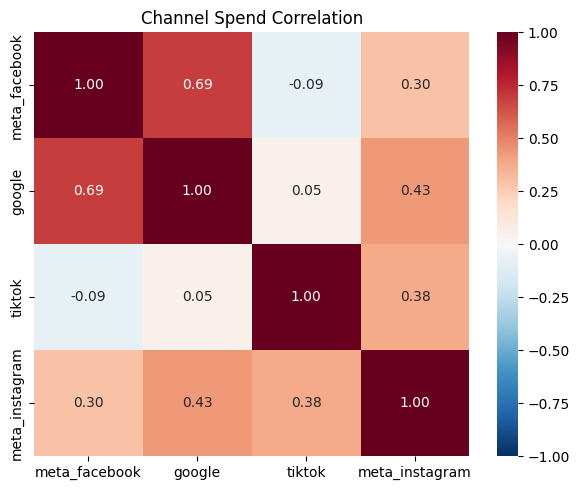

In [14]:
spend_corr = df_fd[["meta_facebook_spend", "google_spend",
                     "tiktok_spend", "meta_instagram_spend"]].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(spend_corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, ax=ax,
            xticklabels=[c.replace("_spend", "") for c in spend_corr.columns],
            yticklabels=[c.replace("_spend", "") for c in spend_corr.columns])
ax.set_title("Channel Spend Correlation")
plt.tight_layout()
plt.show()

## Brand Overview: Key Observations

The correlation heatmap reveals a favorable structure for identification:

- **Meta Facebook and Google (r = 0.69):** The most correlated pair. These
  are the two largest channels and their budgets move together. The model
  will have moderate difficulty separating their individual effects. This is
  the primary identification concern.
- **TikTok is nearly independent** of both Facebook (r = -0.09) and Google
  (r = 0.05). This is ideal: TikTok provides variation that is orthogonal
  to the other channels, making its effect the most cleanly identifiable.
- **Meta Instagram** has moderate correlation with Google (0.43) and TikTok
  (0.38), low with Facebook (0.30). No strong collinearity.

No channel pair exceeds 0.7, which is the informal threshold where
multicollinearity becomes severe. Compare this to the pre-aggregation
situation: Google PMax, Shopping, and Video were physically overlapping
channels that could not be separated. After consolidation, the remaining
4 model channels have distinct enough spend patterns for the sampler
to work with.

# 5. Customer Acquisition vs Retention

37% of Food & Drink's revenue comes from repeat customers. This section
decomposes the business into acquisition (first-time buyers) and retention
(returning customers) to understand what the MMM baseline needs to capture.

Key question: do ads drive new customer acquisition, or do they also affect
returning customers? If first-purchase revenue tracks media spend more closely
than repeat-purchase revenue, ads primarily drive acquisition. The repeat-purchase
base is organic demand, driven by brand loyalty, product quality, and word of
mouth, that exists regardless of ad spend.

This directly informs the MMM: the time-varying intercept in Phase 2b should
absorb the organic repeat-purchase base, while channel contributions explain
the ad-driven first-purchase variation.

In [15]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df_fd["week_start"], y=df_fd["repeat_purchases"],
    name="Repeat Purchases", stackgroup="one",
    line=dict(color="steelblue"),
))
fig.add_trace(go.Scatter(
    x=df_fd["week_start"], y=df_fd["first_purchases"],
    name="First Purchases", stackgroup="one",
    line=dict(color="coral"),
))
fig.update_layout(
    title="Purchase Count Decomposition: First-Time vs Repeat Customers",
    xaxis_title="Week", yaxis_title="Purchases (count)",
    height=450,
)
fig.show()

total_first_n = df_fd["first_purchases"].sum()
total_repeat_n = df_fd["repeat_purchases"].sum()
total_all_n = total_first_n + total_repeat_n
print(f"First purchases: {total_first_n:,.0f} ({total_first_n/total_all_n*100:.1f}%)")
print(f"Repeat purchases: {total_repeat_n:,.0f} ({total_repeat_n/total_all_n*100:.1f}%)")

First purchases: 166,445 (68.5%)
Repeat purchases: 76,603 (31.5%)


In [16]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df_fd["week_start"], y=df_fd["repeat_purchases_net_revenue"],
    name="Repeat Net Revenue", stackgroup="one",
    line=dict(color="steelblue"),
))
fig.add_trace(go.Scatter(
    x=df_fd["week_start"], y=df_fd["first_purchases_net_revenue"],
    name="First Purchase Net Revenue", stackgroup="one",
    line=dict(color="coral"),
))
fig.update_layout(
    title="Revenue Decomposition: First-Time vs Repeat Customers",
    xaxis_title="Week", yaxis_title="Net Revenue ($)",
    height=450,
)
fig.show()

total_first = df_fd["first_purchases_net_revenue"].sum()
total_repeat = df_fd["repeat_purchases_net_revenue"].sum()
total_all = total_first + total_repeat
print(f"First purchase net revenue: ${total_first:,.0f} ({total_first/total_all*100:.1f}%)")
print(f"Repeat purchase net revenue: ${total_repeat:,.0f} ({total_repeat/total_all*100:.1f}%)")

First purchase net revenue: $13,784,045 (63.0%)
Repeat purchase net revenue: $8,085,871 (37.0%)


In [17]:
# Average order value: first vs repeat
df_fd["aov_first"] = (
    df_fd["first_purchases_net_revenue"] / df_fd["first_purchases"]
).replace([np.inf, -np.inf], np.nan)
df_fd["aov_repeat"] = (
    df_fd["repeat_purchases_net_revenue"] / df_fd["repeat_purchases"]
).replace([np.inf, -np.inf], np.nan)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df_fd["week_start"], y=df_fd["aov_first"],
    name="First Purchase AOV", line=dict(color="coral"),
))
fig.add_trace(go.Scatter(
    x=df_fd["week_start"], y=df_fd["aov_repeat"],
    name="Repeat Purchase AOV", line=dict(color="steelblue"),
))
fig.update_layout(
    title="Average Order Value: First-Time vs Repeat Customers",
    xaxis_title="Week", yaxis_title="AOV ($)",
    height=400,
)
fig.show()

print(f"First purchase AOV: ${df_fd['aov_first'].mean():.2f} (std: ${df_fd['aov_first'].std():.2f})")
print(f"Repeat purchase AOV: ${df_fd['aov_repeat'].mean():.2f} (std: ${df_fd['aov_repeat'].std():.2f})")

First purchase AOV: $80.36 (std: $14.27)
Repeat purchase AOV: $104.56 (std: $14.68)


In [18]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df_fd["week_start"], y=df_fd["first_discount_rate"],
    name="First Purchases", line=dict(color="coral"),
))
fig.add_trace(go.Scatter(
    x=df_fd["week_start"], y=df_fd["repeat_discount_rate"],
    name="Repeat Purchases", line=dict(color="steelblue"),
))
fig.update_layout(
    title="Discount Rate Over Time by Customer Type",
    xaxis_title="Week", yaxis_title="Discount Rate (0-1)",
    height=400,
)
fig.show()

print("Discount rate summary:")
for col, label in [
    ("first_discount_rate", "First"),
    ("repeat_discount_rate", "Repeat"),
]:
    vals = df_fd[col]
    print(f"  {label}: mean={vals.mean():.3f}, std={vals.std():.3f}, "
          f"min={vals.min():.3f}, max={vals.max():.3f}")

Discount rate summary:
  First: mean=0.104, std=0.037, min=0.033, max=0.309
  Repeat: mean=0.122, std=0.042, min=0.049, max=0.258


In [19]:
# Discount Rate vs Purchase Count
fig = make_subplots(rows=1, cols=2, subplot_titles=[
    "Acquisition: Discount vs Purchases",
    "Retention: Discount vs Purchases",
])
fig.add_trace(go.Scatter(
    x=df_fd["first_discount_rate"], y=df_fd["first_purchases"],
    mode="markers", marker=dict(color="coral", opacity=0.6),
    name="First",
), row=1, col=1)
fig.add_trace(go.Scatter(
    x=df_fd["repeat_discount_rate"], y=df_fd["repeat_purchases"],
    mode="markers", marker=dict(color="steelblue", opacity=0.6),
    name="Repeat",
), row=1, col=2)
fig.update_xaxes(title_text="Discount Rate", row=1, col=1)
fig.update_xaxes(title_text="Discount Rate", row=1, col=2)
fig.update_yaxes(title_text="Number of Purchases", row=1, col=1)
fig.update_layout(
    title="Discount Rate vs Purchase Count (# of transactions)",
    title_x=0.5,
    height=400, showlegend=False,
)
fig.show()

corr_first = df_fd["first_discount_rate"].corr(df_fd["first_purchases"])
corr_repeat = df_fd["repeat_discount_rate"].corr(df_fd["repeat_purchases"])
print(f"Correlation (discount rate vs purchases):")
print(f"  First: {corr_first:.3f}")
print(f"  Repeat: {corr_repeat:.3f}")

Correlation (discount rate vs purchases):
  First: -0.009
  Repeat: 0.074


In [20]:
# Discount Rate vs Net Revenue
fig = make_subplots(rows=1, cols=2, subplot_titles=[
    "Acquisition: Discount vs Revenue",
    "Retention: Discount vs Revenue",
])
fig.add_trace(go.Scatter(
    x=df_fd["first_discount_rate"], y=df_fd["first_purchases_net_revenue"],
    mode="markers", marker=dict(color="coral", opacity=0.6),
    name="First",
), row=1, col=1)
fig.add_trace(go.Scatter(
    x=df_fd["repeat_discount_rate"], y=df_fd["repeat_purchases_net_revenue"],
    mode="markers", marker=dict(color="steelblue", opacity=0.6),
    name="Repeat",
), row=1, col=2)
fig.update_xaxes(title_text="Discount Rate", row=1, col=1)
fig.update_xaxes(title_text="Discount Rate", row=1, col=2)
fig.update_yaxes(title_text="Net Revenue ($)", row=1, col=1)
fig.update_layout(
    title="Discount Rate vs Net Revenue ($)",
    title_x=0.5,
    height=400, showlegend=False,
)
fig.show()

corr_first = df_fd["first_discount_rate"].corr(df_fd["first_purchases_net_revenue"])
corr_repeat = df_fd["repeat_discount_rate"].corr(df_fd["repeat_purchases_net_revenue"])
print(f"Correlation (discount rate vs net revenue):")
print(f"  First: {corr_first:.3f}")
print(f"  Repeat: {corr_repeat:.3f}")

Correlation (discount rate vs net revenue):
  First: -0.133
  Repeat: -0.013


In [21]:
total_spend = df_fd[["meta_facebook_spend", "google_spend",
                      "tiktok_spend", "meta_instagram_spend"]].sum(axis=1)

fig = make_subplots(rows=1, cols=2, subplot_titles=[
    "Acquisition vs Ad Spend",
    "Retention vs Ad Spend",
])
fig.add_trace(go.Scatter(
    x=total_spend, y=df_fd["first_purchases"],
    mode="markers", marker=dict(color="coral", opacity=0.6),
    name="First",
), row=1, col=1)
fig.add_trace(go.Scatter(
    x=total_spend, y=df_fd["repeat_purchases"],
    mode="markers", marker=dict(color="steelblue", opacity=0.6),
    name="Repeat",
), row=1, col=2)
fig.update_xaxes(title_text="Total Weekly Ad Spend ($)", row=1, col=1)
fig.update_xaxes(title_text="Total Weekly Ad Spend ($)", row=1, col=2)
fig.update_yaxes(title_text="Number of Purchases", row=1, col=1)
fig.update_layout(
    title="Ad Spend vs Purchase Count (# of transactions)",
    title_x=0.5,
    height=400, showlegend=False,
)
fig.show()

corr_first = total_spend.corr(df_fd["first_purchases"])
corr_repeat = total_spend.corr(df_fd["repeat_purchases"])
print(f"Correlation with total ad spend:")
print(f"  First purchase (# of purchases): {corr_first:.3f}")
print(f"  Repeat purchase (# of purchases): {corr_repeat:.3f}")

Correlation with total ad spend:
  First purchase (# of purchases): 0.815
  Repeat purchase (# of purchases): 0.576


In [22]:
total_spend = df_fd[["meta_facebook_spend", "google_spend",
                      "tiktok_spend", "meta_instagram_spend"]].sum(axis=1)

fig = make_subplots(rows=1, cols=2, subplot_titles=[
    "Acquisition vs Ad Spend",
    "Retention vs Ad Spend",
])
fig.add_trace(go.Scatter(
    x=total_spend, y=df_fd["first_purchases_net_revenue"],
    mode="markers", marker=dict(color="coral", opacity=0.6),
    name="First",
), row=1, col=1)
fig.add_trace(go.Scatter(
    x=total_spend, y=df_fd["repeat_purchases_net_revenue"],
    mode="markers", marker=dict(color="steelblue", opacity=0.6),
    name="Repeat",
), row=1, col=2)
fig.update_xaxes(title_text="Total Weekly Ad Spend ($)", row=1, col=1)
fig.update_xaxes(title_text="Total Weekly Ad Spend ($)", row=1, col=2)
fig.update_yaxes(title_text="Net Revenue ($)", row=1, col=1)
fig.update_layout(
    title="Ad Spend vs Net Revenue ($)",
    title_x=0.5,
    height=400, showlegend=False,
)
fig.show()

corr_first = total_spend.corr(df_fd["first_purchases_net_revenue"])
corr_repeat = total_spend.corr(df_fd["repeat_purchases_net_revenue"])
print(f"Correlation with total ad spend:")
print(f"  First purchase net revenue: {corr_first:.3f}")
print(f"  Repeat purchase net revenue: {corr_repeat:.3f}")

Correlation with total ad spend:
  First purchase net revenue: 0.852
  Repeat purchase net revenue: 0.672


## Acquisition vs Retention: Key Findings

**Revenue split:** 63% first-purchase, 37% repeat. By count: 68.5% first,
31.5% repeat.

**Repeat customers spend more per transaction:**
- First-purchase AOV: $80.36
- Repeat-purchase AOV: $104.56

Returning customers spend 30% more per order than new customers. This explains
why repeat is 37% of revenue but only 31.5% of transactions. Repeat buyers
likely know the product range and buy with more confidence (larger baskets,
less price sensitivity on the items they already trust).

**Ad spend correlation confirms ads drive acquisition:**
- First-purchase revenue vs total ad spend: r = 0.852
- Repeat-purchase revenue vs total ad spend: r = 0.672

Both are correlated with spend, but the gap matters. First-purchase revenue
tracks ad spend more tightly. Repeat revenue also moves with spend (repeat
customers likely respond to the same seasonal campaigns), but less so.
The 0.18 gap is the organic loyalty component that exists independent of ads.

**Discounts don't drive demand for this brand:**
- Discount rate vs purchases: r = -0.01 (first), r = 0.07 (repeat)
- Discount rate vs net revenue: r = -0.13 (first), r = -0.01 (repeat)

Despite the brand discounting more heavily for repeat customers (12.2% vs
10.4%), discounting has essentially zero correlation with purchase volume
or revenue for either group. All four correlations are near zero.

This brand's revenue is spend-driven, not price-driven. Customers respond
to ad exposure and product discovery, not discounts. This is a clean setup
for MMM: media is the primary lever. It also explains why the discount rate
control adds zero R² in the OLS (Model D = Model A at 0.792).

**Implications for the MMM:**
- The time-varying intercept (Phase 2b) must absorb the 37% organic repeat base.
  With a fixed intercept, this organic demand gets misattributed to media channels
  (as seen in Phase 2a's -103% baseline).
- The discount rate control (all_discount_rate) is still included for theoretical
  correctness (price elasticity should be controlled for), but we expect a
  near-zero posterior coefficient given the weak correlations observed here.
- The higher repeat AOV ($104 vs $80) means the organic base contributes
  disproportionately to revenue per transaction. The model needs to capture
  this value difference, not just transaction counts.
- The 0.852 correlation between first-purchase revenue and ad spend is encouraging
  for MMM: there is a strong signal for the model to identify. But correlation is
  not causation. The Bayesian model with adstock and saturation will formalize
  this relationship while accounting for carryover and diminishing returns.

# 6. Naive OLS

Our primary modeling target is total revenue (all_purchases_net_revenue).
This is what the business ultimately optimizes: total dollars after discounts.

However, total revenue blends two distinct signals: new customer acquisition
and existing customer retention. Depending on the business goal, either could
be the focus. If customer acquisition cost is high relative to lifetime value,
the business should invest in retention through cheaper channels (email,
loyalty programs). If repeat customers return reliably without intervention,
every ad dollar should go toward acquisition. First_purchases_net_revenue
may be a more direct measure of media effectiveness in theory, but the
business question is about total revenue impact, so that remains our target.

OLS regression here is not the model we'll use for decisions. It has no adstock
(carryover effects), no saturation (diminishing returns), and no causal
identification. Its purpose is purely diagnostic. We ask three questions:

1. Do spend and revenue co-move at all?
2. How much explanatory power do controls add beyond spend alone?
3. Do ads affect acquisition differently than retention?

The sequential OLS (Models A-E) answers questions 1-2 by adding each control 
set independently to the spend-only baseline. The parallel OLS answers 
question 3 by running the same full model on three different targets.

The all-purchases discount rate is shown first since it serves as the MMM
control variable. Note that it is a weighted average of the first-purchase
and repeat-purchase discount rates, weighted by each group's share of gross
revenue. With 63/37 revenue split, the all-purchases rate leans toward the
first-purchase rate.

In [23]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df_fd["week_start"], y=df_fd["all_discount_rate"],
    name="All Purchases Discount Rate", line=dict(color="black"),
))
fig.update_layout(
    title="All-Purchases Discount Rate Over Time (MMM control variable)",
    xaxis_title="Week", yaxis_title="Discount Rate (0-1)",
    height=350,
)
fig.show()

vals = df_fd["all_discount_rate"]
print(f"all_discount_rate: mean={vals.mean():.3f}, std={vals.std():.3f}, "
      f"min={vals.min():.3f}, max={vals.max():.3f}")

all_discount_rate: mean=0.112, std=0.036, min=0.037, max=0.262


In [24]:
cols_spend_active = ["meta_facebook_spend", "google_spend",
                     "tiktok_spend", "meta_instagram_spend"]
print(f"Active spend channels: {cols_spend_active}")

y = df_fd["all_purchases_net_revenue"]

# Model A: spend channels only
X_a = sm.add_constant(df_fd[cols_spend_active])
model_a = sm.OLS(y, X_a).fit()
print(f"\n--- Model A: Spend only (R² = {model_a.rsquared:.3f}) ---")
print(model_a.summary().tables[1])

# Model B: spend + trend + seasonality
cols_seasonal = ["t", "sin_1", "cos_1", "sin_2", "cos_2"]
X_b = sm.add_constant(df_fd[cols_spend_active + cols_seasonal])
model_b = sm.OLS(y, X_b).fit()
print(f"\n--- Model B: Spend + trend/seasonality (R² = {model_b.rsquared:.3f}) ---")
print(model_b.summary().tables[1])

# Model C: spend + organic clicks residual
X_c = sm.add_constant(df_fd[cols_spend_active + ["organic_clicks_residual"]])
model_c = sm.OLS(y, X_c).fit()
print(f"\n--- Model C: Spend + organic_clicks_residual (R² = {model_c.rsquared:.3f}) ---")
print(model_c.summary().tables[1])

# Model D: spend + discount rate
X_d = sm.add_constant(df_fd[cols_spend_active + ["all_discount_rate"]])
model_d = sm.OLS(y, X_d).fit()
print(f"\n--- Model D: Spend + all_discount_rate (R² = {model_d.rsquared:.3f}) ---")
print(model_d.summary().tables[1])

# Model E: everything
cols_all_controls = cols_seasonal + ["organic_clicks_residual", "all_discount_rate"]
X_e = sm.add_constant(df_fd[cols_spend_active + cols_all_controls])
model_e = sm.OLS(y, X_e).fit()
print(f"\n--- Model E: Everything (R² = {model_e.rsquared:.3f}) ---")
print(model_e.summary().tables[1])

Active spend channels: ['meta_facebook_spend', 'google_spend', 'tiktok_spend', 'meta_instagram_spend']

--- Model A: Spend only (R² = 0.791) ---
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 2.227e+04   1.16e+04      1.925      0.057    -660.040    4.52e+04
meta_facebook_spend      1.7911      0.246      7.284      0.000       1.304       2.278
google_spend             2.3118      0.500      4.624      0.000       1.321       3.302
tiktok_spend             2.5523      1.312      1.945      0.054      -0.048       5.152
meta_instagram_spend    13.5599      2.070      6.550      0.000       9.458      17.662

--- Model B: Spend + trend/seasonality (R² = 0.814) ---
                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------


--- Model E: Everything (R² = 0.815) ---
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                    1.326e+04   2.17e+04      0.612      0.542   -2.97e+04    5.62e+04
meta_facebook_spend         1.5899      0.265      5.992      0.000       1.064       2.116
google_spend                1.9514      0.564      3.460      0.001       0.833       3.070
tiktok_spend                3.6455      1.704      2.140      0.035       0.267       7.024
meta_instagram_spend       10.3554      2.632      3.934      0.000       5.136      15.575
t                         532.5685    231.346      2.302      0.023      73.801     991.336
sin_1                    1.245e+04   1.06e+04      1.170      0.245   -8655.633    3.36e+04
cos_1                   -8910.7478   7315.171     -1.218      0.226   -2.34e+04    5595.512
sin_2                    1.814e+04   8

In [25]:
df_compare = pd.DataFrame([
    {"model": "A", "regressors": "spend only", "R²": model_a.rsquared, "adj_R²": model_a.rsquared_adj},
    {"model": "B", "regressors": "A + trend + seasonality", "R²": model_b.rsquared, "adj_R²": model_b.rsquared_adj},
    {"model": "C", "regressors": "A + organic residual", "R²": model_c.rsquared, "adj_R²": model_c.rsquared_adj},
    {"model": "D", "regressors": "A + discount rate", "R²": model_d.rsquared, "adj_R²": model_d.rsquared_adj},
    {"model": "E", "regressors": "A + everything", "R²": model_e.rsquared, "adj_R²": model_e.rsquared_adj},
])
df_compare[["R²", "adj_R²"]] = df_compare[["R²", "adj_R²"]].round(3)
df_compare  # type: ignore

,model,regressors,R²,adj_R²
0,A,spend only,0.791,0.784
1,B,A + trend + seasonality,0.814,0.798
2,C,A + organic residual,0.795,0.785
3,D,A + discount rate,0.792,0.782
4,E,A + everything,0.815,0.795


In [26]:
spend_cols = ["meta_facebook_spend", "google_spend",
              "tiktok_spend", "meta_instagram_spend"]
shared_controls = ["organic_clicks_residual", "sin_1", "cos_1", "sin_2", "cos_2"]

ols_configs = [
    {
        "label": "All Purchases",
        "target": "all_purchases_net_revenue",
        "discount": "all_discount_rate",
    },
    {
        "label": "First Purchases (acquisition)",
        "target": "first_purchases_net_revenue",
        "discount": "first_discount_rate",
    },
    {
        "label": "Repeat Purchases (retention)",
        "target": "repeat_purchases_net_revenue",
        "discount": "repeat_discount_rate",
    },
]

print("Naive OLS with Full Controls (Model E)")
for i, cfg in enumerate(ols_configs):
    X_cols = spend_cols + [cfg["discount"]] + shared_controls
    X = df_fd[X_cols].values
    y_ols = df_fd[cfg["target"]].values

    reg = LinearRegression().fit(X, y_ols)
    r2 = reg.score(X, y_ols)
    
    print(f"\n{i+1}. {cfg['label']} (target: {cfg['target']})")
    print(f"  R²: {r2:.3f}")

Naive OLS with Full Controls (Model E)

1. All Purchases (target: all_purchases_net_revenue)
  R²: 0.805

2. First Purchases (acquisition) (target: first_purchases_net_revenue)
  R²: 0.810

3. Repeat Purchases (retention) (target: repeat_purchases_net_revenue)
  R²: 0.604


## OLS Takeaways

**Question 1: Does the signal exist?** Yes. Spend alone explains 79.2% of
weekly revenue variation (Model A). This is a strong baseline that justifies
building the full Bayesian MMM. The relationship between ad spend and revenue
is not subtle.

**Question 2: Do controls add explanatory power?** Each control set is tested
independently against the spend-only baseline (Model A: 79.2%):

| Model | What's added to spend | R² | Lift over A |
|---|---|---|---|
| B | Trend + seasonality | 0.814 | +2.2pp |
| C | Organic clicks residual | 0.795 | +0.3pp |
| D | Discount rate | 0.792 | +0.0pp |
| E | Everything combined | 0.815 | +2.3pp |

Trend and seasonality provide the only meaningful lift. The organic clicks
residual and discount rate add almost nothing individually in a linear
framework. With everything combined (Model E), the improvement is only 2.3
points over spend alone. This does not mean these controls are useless in
the MMM: adstock and saturation change the attribution structure, which may
reveal control effects that OLS cannot detect.

**Question 3: Do ads drive acquisition more than retention?**
Clearly yes, and by a wide margin.

| Target | R² (Model E) | Interpretation |
|---|---|---|
| All purchases | 0.805 | Media + controls explain 80% of total revenue |
| First purchases (acquisition) | 0.810 | Slightly better fit for new customers |
| Repeat purchases (retention) | 0.604 | Much weaker fit for returning customers |

Media spend explains first-purchase revenue about as well as total revenue,
but explains only 60% of repeat-purchase revenue. The 20-point gap between
first (0.810) and repeat (0.604) is the organic loyalty signal: roughly a
fifth of repeat-purchase variation has nothing to do with ads or any control
we measure. This is the demand that the MMM's time-varying intercept must
absorb in Phase 2b.

**A note on the OLS coefficients:** While we report coefficients above, the
standard errors and p-values should not be taken at face value for two reasons:

1. **The error term is not i.i.d.** Weekly revenue data is autocorrelated:
   a good week tends to follow a good week. OLS standard errors assume
   independent errors, making them too small and p-values too optimistic.
   The fix within a linear framework is time-series regression with
   Newey-West (HAC) standard errors.

2. **Channel effects are assumed constant.** The model forces Meta Facebook
   to have the same marginal effect in week 1 as week 116. If effectiveness
   changes over time (audience fatigue, creative rotation, competitive entry),
   the coefficient is an average that masks the trend. The fix within a linear
   framework is interacting spend variables with time (spend * t) to allow
   time-dependent effects.

We do not pursue either fix here because the goal is not to draw inference
from OLS. The Bayesian MMM in Phase 2 addresses these issues structurally:
adstock captures carryover effects, saturation captures diminishing returns,
and a time-varying intercept (Phase 2b) captures baseline drift.

**What linear models do better than MMM:** OLS has real advantages that are
easy to overlook. It is fast (instant vs 30-minute MCMC fits), transparent
(every assumption is visible, no sampler diagnostics to worry about),
and has well-understood inference when its assumptions hold. OLS never
diverges, never has low ESS, and never produces prior-dominated posteriors.
When the true relationship is approximately linear and the sample is large
enough, OLS gives you the right answer with less machinery. The reason we
move to Bayesian MMM is that the advertising response is fundamentally
nonlinear (adstock + saturation), and 116 weekly observations cannot support
frequentist estimation of 20+ nonlinear parameters. The Bayesian framework
is a necessity for this problem, not a preference.

# 7. Diagnostics and Handoff

Before passing this data to the Bayesian MMM, we check whether the target
variable is stationary using the Augmented Dickey-Fuller test.

In [27]:
from statsmodels.tsa.stattools import adfuller

for col, label in [
    ("all_purchases", "All Purchases (count)"),
    ("all_purchases_net_revenue", "All Purchases Net Revenue ($)"),
]:
    result = adfuller(df_fd[col].dropna())
    print(f"{label}:")
    print(f"  ADF statistic: {result[0]:.3f}")
    print(f"  p-value: {result[1]:.4f}")
    print(f"  Stationary: {'Yes' if result[1] < 0.05 else 'No (p > 0.05)'}")
    print()

All Purchases (count):
  ADF statistic: -3.985
  p-value: 0.0015
  Stationary: Yes

All Purchases Net Revenue ($):
  ADF statistic: -2.369
  p-value: 0.1507
  Stationary: No (p > 0.05)



## Stationarity Results

| Variable | ADF statistic | p-value | Stationary? |
|---|---|---|---|
| All purchases (count) | -3.985 | 0.002 | Yes |
| All purchases net revenue ($) | -2.369 | 0.151 | No |

Purchase counts are stationary but net revenue is not. This divergence makes
sense: the number of transactions may be stable while the revenue per
transaction drifts (changing product mix, price increases, or evolving
discount patterns).

This is directly relevant to Phase 2b. A non-stationary target means the
data-generating process has a shifting level over time. A fixed intercept
(Phase 2a) forces a single baseline for all 116 weeks, which cannot track
this drift. The result: the model compensates by over-attributing revenue
to media channels, producing the -103% baseline we observed.

The time-varying intercept in Phase 2b is not just a modeling preference.
For a non-stationary target, it is a statistical necessity. The GP-based
baseline can track the shifting revenue level, allowing channel contributions
to explain only the variation genuinely attributable to spend changes.

In [28]:
os.makedirs("data/processed", exist_ok=True)

path = "data/processed/food_drink.csv"
df_fd.to_csv(path, index=False)
print(f"Saved food_drink: {df_fd.shape} -> {path}")

# Verify derived columns
saved = pd.read_csv(path, nrows=1)
assert "all_purchases_net_revenue" in saved.columns, "Missing net_revenue!"
assert "repeat_purchases" in saved.columns, "Missing repeat_purchases!"
assert "organic_clicks_residual" in saved.columns, "Missing organic_clicks_residual!"
assert "all_discount_rate" in saved.columns, "Missing all_discount_rate!"
assert "google_spend" in saved.columns, "Missing google_spend!"
print(f"Verified: {len(saved.columns)} columns")

Saved food_drink: (116, 60) -> data/processed/food_drink.csv
Verified: 60 columns


## Handoff to Phase 2

The processed CSV contains 116 weeks of Food & Drink data with:
- 4 media spend channels (Meta Facebook, Google, TikTok, Meta Instagram)
- 2 control variables (all_discount_rate, organic_clicks_residual)
- Target: all_purchases_net_revenue (non-stationary, motivates time-varying intercept)
- Time features: t, sin_1, cos_1, sin_2, cos_2, week_start
- Customer segmentation: first/repeat purchases, units, revenue, discount rates
- Meta_other profiled but excluded from model (0.01% of spend)

Phase 2a fits the library model (PyMC-Marketing) with fixed intercept
and default settings. It produces good aggregate fit but economically
implausible decomposition, establishing the baseline for comparison.

Phase 2b adds a time-varying intercept (Gaussian Process) to address
the non-stationarity and baseline problem. If residual autocorrelation
persists, AR(1) errors are the next structural fix.